In [ ]:
from mpramnist.Evfratov2017 import EvfratovDataset
from mpramnist.Evfratov2017 import LitModel_Evfratov

from mpramnist.models import HumanLegNet
from mpramnist.models import initialize_weights

import mpramnist.transforms as t

import torch.nn as nn
from torch.utils.data import DataLoader
import lightning.pytorch as L

BATCH_SIZE = 32
NUM_WORKERS = 103

# preprocessing
train_transform = t.Compose([t.ReverseComplement(0.5),t.Seq2Tensor(),])
test_transform = t.Compose([t.Seq2Tensor(),t.ReverseComplement(0),])

The dataset has a pair of attributes:

**merge_last_classes** — determines whether the last two classes should be merged into one.

**length_of_seq** — determines which dataset to use. "23" refers to the dataset with sequences of length 23, and "33" refers to the dataset with sequences of length 33. The default is "23".


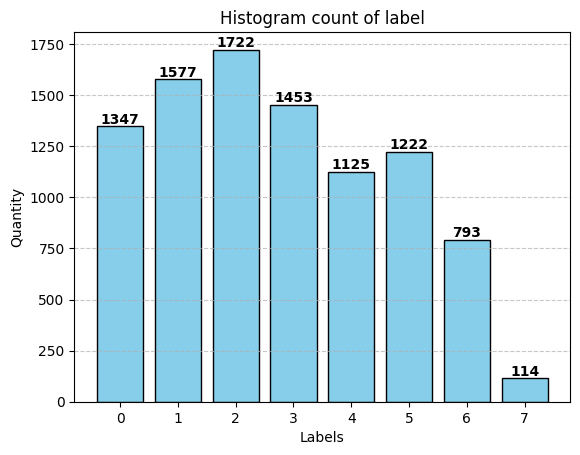

In [ ]:
# Merging last 2 classes
merge_last_classes = False

train_dataset = EvfratovDataset(
    split="train",
    merge_last_classes=merge_last_classes,
    length_of_seq=23,  # or 33
    transform=train_transform,
    root="../data/",
)  # use "train" for default training set
# Plot histogram with 8 classes
train_dataset.hist_plot()

# too few examples in group 8

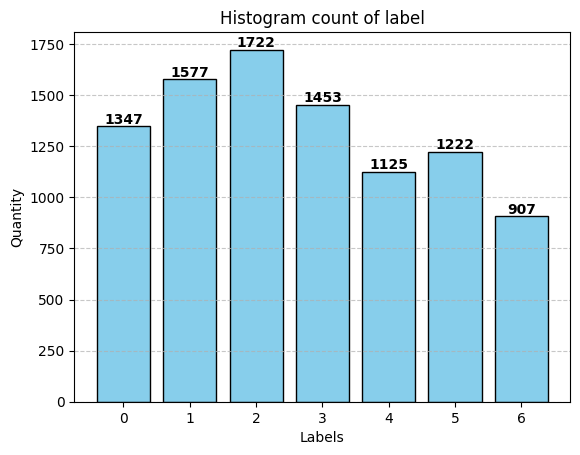

In [ ]:
# Therefore, to balance class representation, we propose merging the last two classes into one.
merge_last_classes = True

train_dataset = EvfratovDataset(
    split="train",
    merge_last_classes=merge_last_classes,
    length_of_seq=23,  # or 33
    transform=train_transform,
    root="../data/",
)  # use "train" for default training set
# Plot histogram with 7 classes
train_dataset.hist_plot()

# looks better

In [ ]:
# Sequences length of 23
length_of_seq = 23
merge_last_classes = True

train_dataset = EvfratovDataset(split="train",merge_last_classes=merge_last_classes,length_of_seq=length_of_seq,transform=train_transform,root="../data/",)  # use "train" for default training set
val_dataset = EvfratovDataset(split="val",merge_last_classes=merge_last_classes,length_of_seq=length_of_seq,transform=test_transform,root="../data/",)  # use "val" for default validation set
test_dataset = EvfratovDataset(split="test",merge_last_classes=merge_last_classes,length_of_seq=length_of_seq,transform=test_transform,root="../data/",)  # use "test" for default test set

# encapsulate data into dataloader form
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Use train_dataset.n_classes to define number of used classes
N_CLASSES = train_dataset.n_classes
in_channels = len(train_dataset[0][0])

In [ ]:
model = HumanLegNet(
    in_ch=in_channels,
    output_dim=N_CLASSES,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[80, 96, 112, 128],
    pool_sizes=[2, 2, 2, 2],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Evfratov(model=model,loss=nn.CrossEntropyLoss(),n_classes=N_CLASSES,weight_decay=1e-1,lr=1e-2,print_each=1)

# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=5,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    enable_model_summary=False,
)

# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)

# To see real number of examples in class - plot histogram on test dataset
test_dataset.hist_plot()

In [ ]:
# Sequences length of 33
length_of_seq = 33
merge_last_classes = False

train_dataset = EvfratovDataset(split="train",merge_last_classes=merge_last_classes,length_of_seq=length_of_seq,transform=train_transform,root="../data/",)  # use "train" for default training set
val_dataset = EvfratovDataset(split="val",merge_last_classes=merge_last_classes,length_of_seq=length_of_seq,transform=test_transform,root="../data/",)  # use "val" for default validation set
test_dataset = EvfratovDataset(split="test",merge_last_classes=merge_last_classes,length_of_seq=length_of_seq,transform=test_transform,root="../data/",)  # use "test" for default test set

# encapsulate data into dataloader form
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Use train_dataset.n_classes to define number of used classes
N_CLASSES = train_dataset.n_classes
in_channels = len(train_dataset[0][0])

train_dataset.hist_plot()

In [ ]:
model = HumanLegNet(
    in_ch=in_channels,
    output_dim=N_CLASSES,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[80, 96, 112, 128],
    pool_sizes=[2, 2, 2, 2],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Evfratov(
    model=model,
    loss=nn.CrossEntropyLoss(),
    n_classes=N_CLASSES,
    weight_decay=1e-2,
    lr=1e-2,
    print_each=1,
)

# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[0],
    max_epochs=5,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
    enable_model_summary=False,
)

# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)

# To see real number of examples in class - plot histogram on test dataset
test_dataset.hist_plot()
